In [3]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter
from datetime import datetime

import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split

# Add project root
project_root = Path.cwd().parent.parent
sys.path.insert(0, str(project_root))

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

print(f"Project root: {project_root}")
print("Libraries imported successfully.")

Project root: /home/rdb/Documents/nirban_documents/python_programs/counterfactual_basis_kernel
Libraries imported successfully.


In [5]:
DATA_PATH = "/home/rdb/Documents/nirban_documents/python_programs/counterfactual_basis_kernel/data/processed/AQI_India/"
df = pd.read_csv(DATA_PATH + "AQI_Station_India.csv")
print(f"Shape: {df.shape}")
df.head(10)

/tmp/ipykernel_515218/1887434166.py:2: DtypeWarning: Columns (16,38) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(DATA_PATH + "AQI_Station_India.csv")


Shape: (2589083, 39)


,Unnamed: 0,StationId,Datetime,PM2.5,PM10,NO,NO2,NOx,NH3,CO,...,PM2.5_SubIndex,PM10_SubIndex,SO2_SubIndex,NOx_SubIndex,NH3_SubIndex,CO_SubIndex,O3_SubIndex,Checks,AQI_calculated,AQI_bucket_calculated
0,0,AP001,2017-11-24 17:00:00,60.50,98.00,2.35,30.80,18.25,8.50,0.1,...,0.0,0.0,0.0,0.0,0.0,5.0,138.823529,2,NaN,NaN
1,1,AP001,2017-11-24 18:00:00,65.50,111.25,2.70,24.20,15.07,9.77,0.1,...,0.0,0.0,0.0,0.0,0.0,5.0,138.823529,2,NaN,NaN
2,2,AP001,2017-11-24 19:00:00,80.00,132.00,2.10,25.18,15.15,12.02,0.1,...,0.0,0.0,0.0,0.0,0.0,5.0,138.823529,2,NaN,NaN
3,3,AP001,2017-11-24 20:00:00,81.50,133.25,1.95,16.25,10.23,11.58,0.1,...,0.0,0.0,0.0,0.0,0.0,5.0,138.823529,2,NaN,NaN
4,4,AP001,2017-11-24 21:00:00,75.25,116.00,1.43,17.48,10.43,12.03,0.1,...,0.0,0.0,0.0,0.0,0.0,5.0,138.823529,2,NaN,NaN
5,5,AP001,2017-11-24 22:00:00,69.25,108.25,0.70,18.47,10.38,13.80,0.1,...,0.0,0.0,0.0,0.0,0.0,5.0,138.823529,2,NaN,NaN
6,6,AP001,2017-11-24 23:00:00,67.50,111.50,1.05,12.15,7.30,17.65,0.1,...,0.0,0.0,0.0,0.0,0.0,5.0,138.823529,2,NaN,NaN
7,7,AP001,2017-11-25 00:00:00,68.00,111.00,1.25,14.12,8.50,20.28,0.1,...,0.0,0.0,0.0,0.0,0.0,5.0,138.823529,2,NaN,NaN
8,8,AP001,2017-11-25 01:00:00,73.00,102.00,0.30,14.30,7.90,11.50,0.3,...,0.0,0.0,0.0,0.0,0.0,15.0,131.617647,2,NaN,NaN
9,9,AP001,2017-11-25 02:00:00,81.00,123.00,0.80,24.85,13.88,10.28,0.1,...,0.0,0.0,0.0,0.0,0.0,15.0,131.617647,2,NaN,NaN


In [6]:
df.describe()

,Unnamed: 0,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,...,O3_8hr_max,PM2.5_SubIndex,PM10_SubIndex,SO2_SubIndex,NOx_SubIndex,NH3_SubIndex,CO_SubIndex,O3_SubIndex,Checks,AQI_calculated
count,2.589083e+06,1.941394e+06,1.469831e+06,2.035372e+06,2.060110e+06,2.098275e+06,1.352465e+06,2.089781e+06,1.846346e+06,1.863110e+06,...,1.928356e+06,2.589083e+06,2.589083e+06,2.589083e+06,2.589083e+06,2.589083e+06,2.589083e+06,2.589083e+06,2.589083e+06,2.017972e+06
mean,1.294541e+06,8.086481e+01,1.584839e+02,2.278825e+01,3.523689e+01,4.055115e+01,2.870856e+01,1.502366e+00,1.211602e+01,3.806408e+01,...,5.807241e+01,1.121600e+02,8.096094e+01,1.068298e+01,3.947957e+01,3.727238e+00,6.182169e+01,4.454831e+01,4.836953e+00,1.801936e+02
std,7.474040e+05,8.947618e+01,1.397883e+02,4.846146e+01,3.497508e+01,5.590894e+01,2.753244e+01,6.292445e+00,1.467385e+01,4.710653e+01,...,6.016598e+01,1.272013e+02,1.095745e+02,1.344759e+01,4.801926e+01,5.684035e+00,8.650462e+01,5.626962e+01,2.420303e+00,1.404327e+02
min,0.000000e+00,1.000000e-02,1.000000e-02,1.000000e-02,1.000000e-02,0.000000e+00,1.000000e-02,0.000000e+00,1.000000e-02,1.000000e-02,...,1.000000e-02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,5.000000e+00
25%,6.472705e+05,2.816000e+01,6.400000e+01,3.050000e+00,1.310000e+01,1.135000e+01,1.123000e+01,4.100000e-01,4.250000e+00,1.102000e+01,...,2.234000e+01,0.000000e+00,0.000000e+00,0.000000e+00,4.369792e+00,0.000000e+00,1.650000e+01,0.000000e+00,4.000000e+00,8.400000e+01
50%,1.294541e+06,5.259000e+01,1.162500e+02,7.150000e+00,2.479000e+01,2.286000e+01,2.235000e+01,8.000000e-01,8.250000e+00,2.475000e+01,...,4.365000e+01,6.581667e+01,4.544667e+01,7.319792e+00,2.517656e+01,8.459375e-01,5.050000e+01,2.850000e+01,5.000000e+00,1.310000e+02
75%,1.941812e+06,9.774000e+01,2.040000e+02,1.858000e+01,4.548000e+01,4.570000e+01,3.778000e+01,1.380000e+00,1.453000e+01,4.953000e+01,...,7.706000e+01,1.667583e+02,1.256944e+02,1.505312e+01,5.293776e+01,6.141875e+00,9.050000e+01,6.347000e+01,7.000000e+00,2.590000e+02
max,2.589082e+06,1.000000e+03,1.000000e+03,5.000000e+02,4.999900e+02,5.000000e+02,4.999700e+02,4.985700e+02,1.999600e+02,9.970000e+02,...,9.970000e+02,9.769231e+02,1.112500e+03,1.322537e+02,4.327443e+02,1.039766e+02,3.132765e+03,5.107607e+02,7.000000e+00,3.133000e+03


In [7]:
print("Columns and dtypes:")
print("-" * 40)
for col in df.columns:
    print(f"  {col:30s} | dtype: {str(df[col].dtype):10s} | unique: {df[col].nunique():6d} | nulls: {df[col].isna().sum():6d} ({df[col].isna().mean()*100:.2f}%)")

Columns and dtypes:
----------------------------------------
  Unnamed: 0                     | dtype: int64      | unique: 2589083 | nulls:      0 (0.00%)
  StationId                      | dtype: object     | unique:    110 | nulls:      0 (0.00%)
  Datetime                       | dtype: object     | unique:  48192 | nulls:      0 (0.00%)
  PM2.5                          | dtype: float64    | unique:  45086 | nulls: 647689 (25.02%)
  PM10                           | dtype: float64    | unique:  56960 | nulls: 1119252 (43.23%)
  NO                             | dtype: float64    | unique:  36985 | nulls: 553711 (21.39%)
  NO2                            | dtype: float64    | unique:  26703 | nulls: 528973 (20.43%)
  NOx                            | dtype: float64    | unique:  40690 | nulls: 490808 (18.96%)
  NH3                            | dtype: float64    | unique:  20523 | nulls: 1236618 (47.76%)
  CO                             | dtype: float64    | unique:   7263 | nulls: 49930

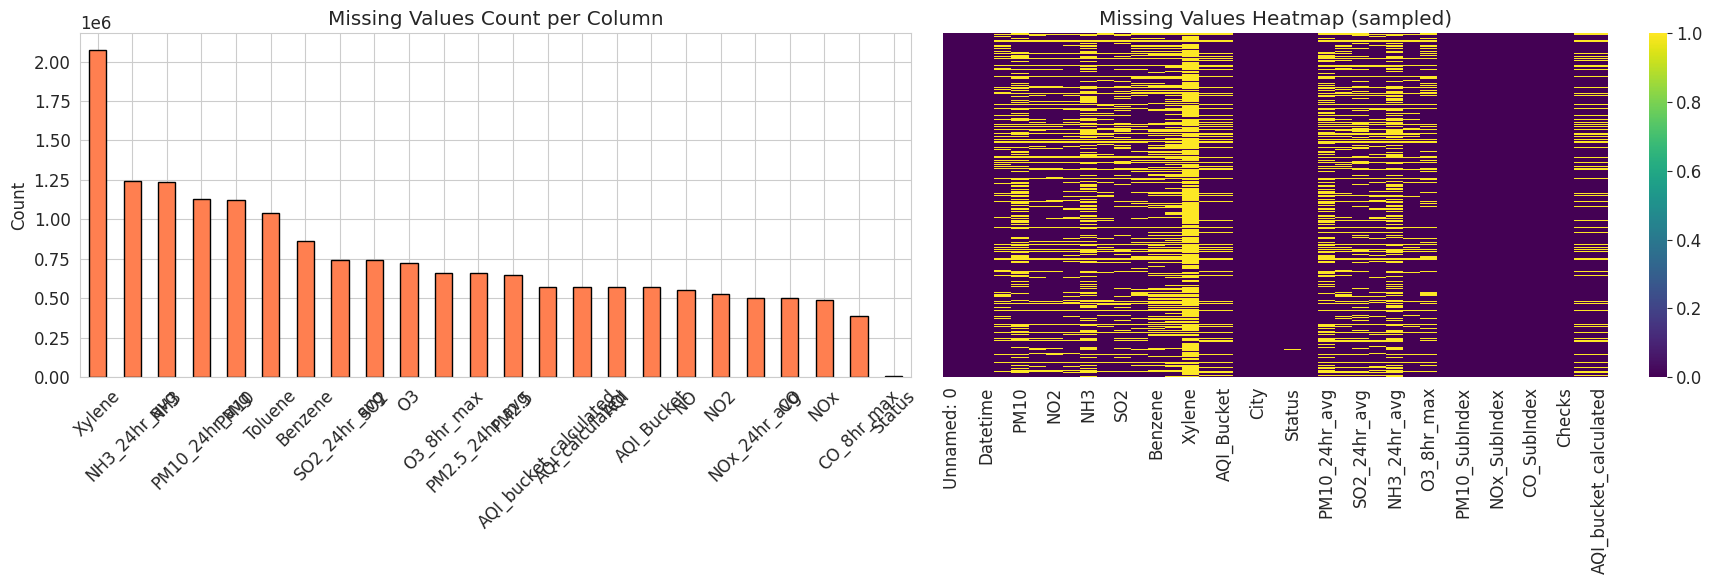

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Bar chart of missing values
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
if len(missing) > 0:
    missing.plot(kind='bar', ax=axes[0], color='coral', edgecolor='black')
    axes[0].set_title('Missing Values Count per Column')
    axes[0].set_ylabel('Count')
    axes[0].tick_params(axis='x', rotation=45)
else:
    axes[0].text(0.5, 0.5, 'No missing values!', ha='center', va='center', fontsize=16)
    axes[0].set_title('Missing Values Count per Column')

# Missing values heatmap (sample if too large)
sample_df = df.sample(min(1000, len(df)), random_state=42) if len(df) > 1000 else df
sns.heatmap(sample_df.isna(), cbar=True, yticklabels=False, ax=axes[1], cmap='viridis')
axes[1].set_title('Missing Values Heatmap (sampled)')

plt.tight_layout()
plt.show()

In [18]:
# Identify date columns (try to detect)
date_cols = []
for col in df.columns:
    if df[col].dtype == 'object':
        try:
            pd.to_datetime(df[col].dropna().head(100))
            date_cols.append(col)
        except:
            pass

# Identify categorical vs numeric columns
categorical_cols = [col for col in df.select_dtypes(include=['object', 'category']).columns if col not in date_cols]
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

print(f"Date columns:        {date_cols}")
print(f"Categorical columns: {categorical_cols}")
print(f"Numeric columns:     {numeric_cols}")
print(f"\nTotal: {len(date_cols)} date + {len(categorical_cols)} categorical + {len(numeric_cols)} numeric = {len(date_cols)+len(categorical_cols)+len(numeric_cols)}")

/tmp/ipykernel_515218/3784738526.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(df[col].dropna().head(100))
/tmp/ipykernel_515218/3784738526.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(df[col].dropna().head(100))


Date columns:        ['Datetime', 'Date']
Categorical columns: ['StationId', 'AQI_Bucket', 'StationName', 'City', 'State', 'Status', 'AQI_bucket_calculated']
Numeric columns:     ['Unnamed: 0', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'PM10_24hr_avg', 'PM2.5_24hr_avg', 'SO2_24hr_avg', 'NOx_24hr_avg', 'NH3_24hr_avg', 'CO_8hr_max', 'O3_8hr_max', 'PM2.5_SubIndex', 'PM10_SubIndex', 'SO2_SubIndex', 'NOx_SubIndex', 'NH3_SubIndex', 'CO_SubIndex', 'O3_SubIndex', 'Checks', 'AQI_calculated']

Total: 2 date + 7 categorical + 30 numeric = 39


In [20]:
# Parse the date column
if len(date_cols) > 0:
    date_col = date_cols[0]  # Use the first detected date column
    df[date_col] = pd.to_datetime(df[date_col])
    df = df.sort_values(by=date_col).reset_index(drop=True)
    print(f"Parsed '{date_col}' as datetime.")
    print(f"Date range: {df[date_col].min()} to {df[date_col].max()}")
    print(f"Duration: {df[date_col].max() - df[date_col].min()}")
else:
    date_col = None
    print("No date column detected. Treating data as sequential by index.")

df.head()

Parsed 'Datetime' as datetime.
Date range: 2015-01-01 01:00:00 to 2020-07-01 00:00:00
Duration: 2007 days 23:00:00


,Unnamed: 0,StationId,Datetime,PM2.5,PM10,NO,NO2,NOx,NH3,CO,...,PM2.5_SubIndex,PM10_SubIndex,SO2_SubIndex,NOx_SubIndex,NH3_SubIndex,CO_SubIndex,O3_SubIndex,Checks,AQI_calculated,AQI_bucket_calculated
0,2261543,TN003,2015-01-01 01:00:00,NaN,NaN,9.36,10.65,11.85,6.36,0.89,...,0.0,0.0,0.0,0.0,0.0,44.500000,0.00,1,NaN,NaN
1,1067398,DL033,2015-01-01 01:00:00,NaN,NaN,148.44,39.00,219.25,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.000000,3.00,1,NaN,NaN
2,1697783,MH005,2015-01-01 01:00:00,NaN,NaN,NaN,NaN,24.38,NaN,0.00,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.00,0,NaN,NaN
3,1394227,KA003,2015-01-01 01:00:00,NaN,NaN,1.62,14.85,8.46,NaN,0.19,...,0.0,0.0,0.0,0.0,0.0,9.500000,12.41,2,NaN,NaN
4,733579,DL021,2015-01-01 01:00:00,NaN,NaN,NaN,65.00,488.03,NaN,18.00,...,0.0,0.0,0.0,0.0,0.0,305.882353,3.50,2,NaN,NaN


In [ ]:
# sort by station ID

Parsed 'Datetime' as datetime.
Date range: 2015-01-01 01:00:00 to 2020-07-01 00:00:00
Duration: 2007 days 23:00:00


,Unnamed: 0,StationId,Datetime,PM2.5,PM10,NO,NO2,NOx,NH3,CO,...,PM2.5_SubIndex,PM10_SubIndex,SO2_SubIndex,NOx_SubIndex,NH3_SubIndex,CO_SubIndex,O3_SubIndex,Checks,AQI_calculated,AQI_bucket_calculated
0,2261543,TN003,2015-01-01 01:00:00,NaN,NaN,9.36,10.65,11.85,6.36,0.89,...,0.0,0.0,0.0,0.0,0.0,44.500000,0.00,1,NaN,NaN
1,1067398,DL033,2015-01-01 01:00:00,NaN,NaN,148.44,39.00,219.25,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.000000,3.00,1,NaN,NaN
2,1697783,MH005,2015-01-01 01:00:00,NaN,NaN,NaN,NaN,24.38,NaN,0.00,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.00,0,NaN,NaN
3,1394227,KA003,2015-01-01 01:00:00,NaN,NaN,1.62,14.85,8.46,NaN,0.19,...,0.0,0.0,0.0,0.0,0.0,9.500000,12.41,2,NaN,NaN
4,733579,DL021,2015-01-01 01:00:00,NaN,NaN,NaN,65.00,488.03,NaN,18.00,...,0.0,0.0,0.0,0.0,0.0,305.882353,3.50,2,NaN,NaN



Column: StationId  |  Unique: 110
StationId
DL007    48192
DL033    48192
DL021    48192
DL013    48192
DL008    48192
UP012    48192
TN001    48192
UP014    48192
TN004    48192
TN003    48192
MH005    48192
KA009    48192
KA003    48192
GJ001    48192
DL014    48128
TG005    48107
DL002    45950
DL031    45950
DL028    45872
DL019    45826
Name: count, dtype: int64

Column: AQI_Bucket  |  Unique: 6
AQI_Bucket
Moderate        675008
Satisfactory    530164
Very Poor       301150
Poor            239990
Good            152113
Severe          120468
Name: count, dtype: int64


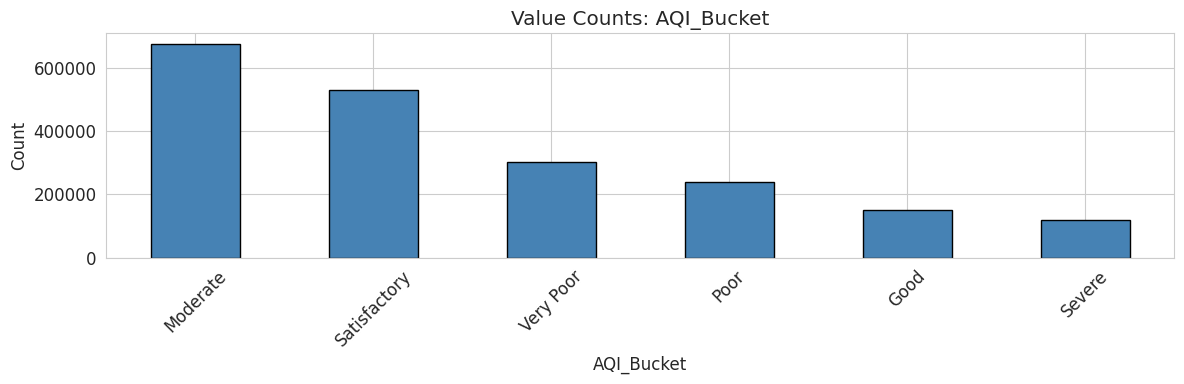


Column: StationName  |  Unique: 110
StationName
CRRI Mathura Road, Delhi - IMD             48192
Shadipur, Delhi - CPCB                     48192
NSIT Dwarka, Delhi - CPCB                  48192
IHBAS, Dilshad Garden, Delhi - CPCB        48192
DTU, Delhi - CPCB                          48192
Central School, Lucknow - CPCB             48192
Alandur Bus Depot, Chennai - CPCB          48192
Lalbagh, Lucknow - CPCB                    48192
Velachery Res. Area, Chennai - CPCB        48192
Manali, Chennai - CPCB                     48192
Bandra, Mumbai - MPCB                      48192
Peenya, Bengaluru - CPCB                   48192
BWSSB Kadabesanahalli, Bengaluru - CPCB    48192
Maninagar, Ahmedabad - GPCB                48192
ITO, Delhi - CPCB                          48128
Sanathnagar, Hyderabad - TSPCB             48107
Anand Vihar, Delhi - DPCC                  45950
R K Puram, Delhi - DPCC                    45950
Punjabi Bagh, Delhi - DPCC                 45872
Mandir Marg, Delhi -

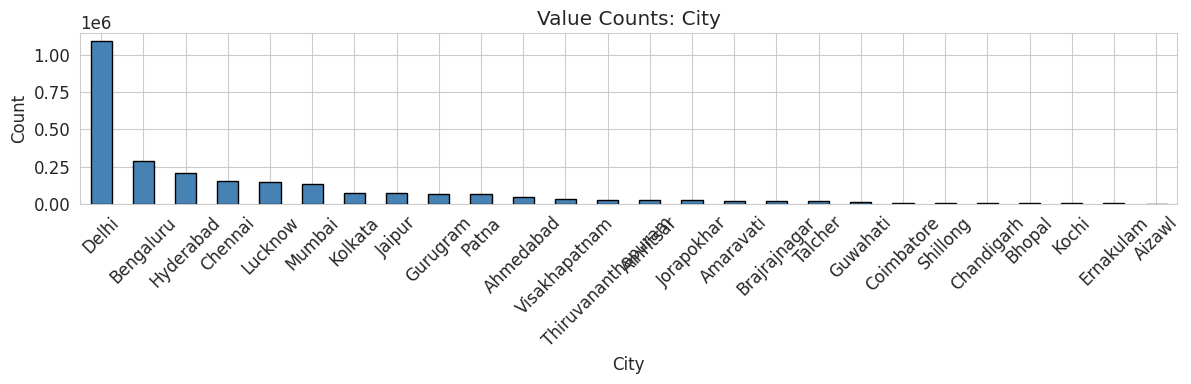


Column: State  |  Unique: 21
State
Delhi             1087388
Karnataka          287564
Telangana          209831
Tamil Nadu         162877
Uttar Pradesh      146210
Maharashtra        131750
West Bengal         75717
Rajasthan           74032
Haryana             67804
Bihar               64031
Andhra Pradesh      57837
Gujarat             48192
Odisha              44629
Kerala              37677
Punjab              29269
Jharkhand           28025
Assam               12002
Meghalaya            7402
Chandigarh           7263
Madhya Pradesh       6903
Name: count, dtype: int64


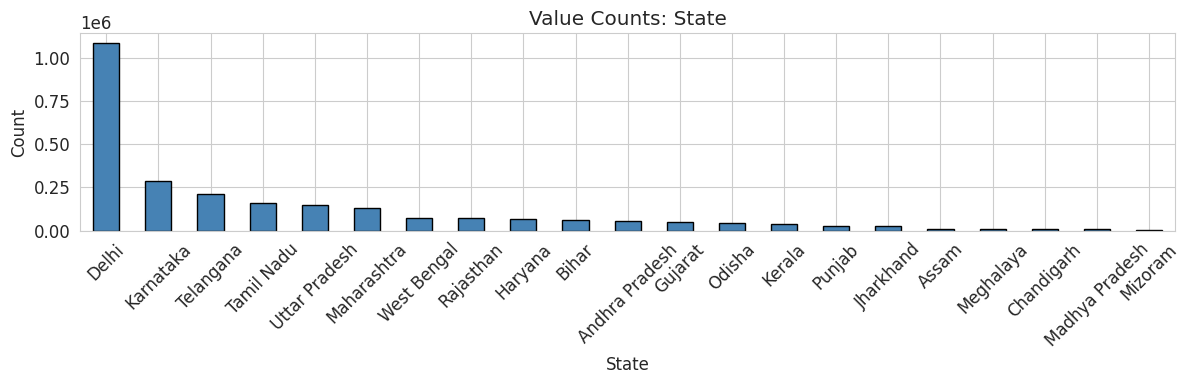


Column: Status  |  Unique: 2
Status
Active      2542823
Inactive      38554
Name: count, dtype: int64


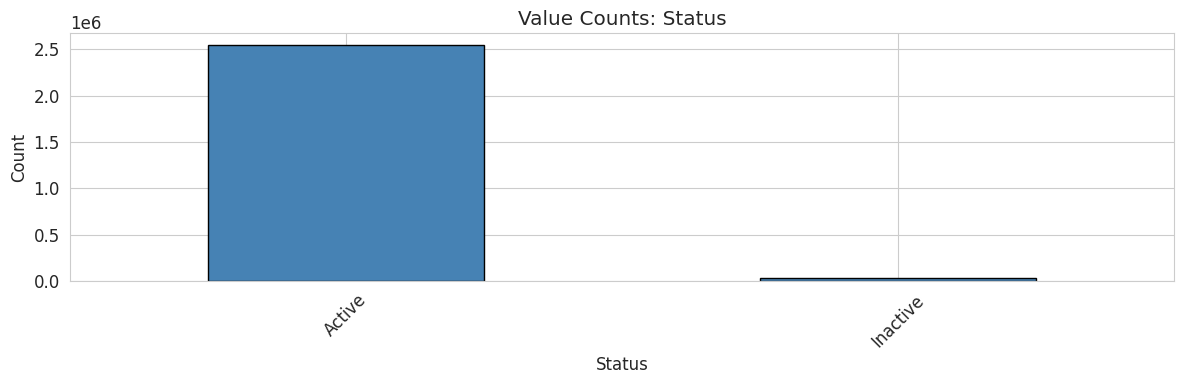


Column: AQI_bucket_calculated  |  Unique: 6
AQI_bucket_calculated
Moderate        674415
Satisfactory    529974
Very Poor       301128
Poor            239914
Good            152073
Severe          120468
Name: count, dtype: int64


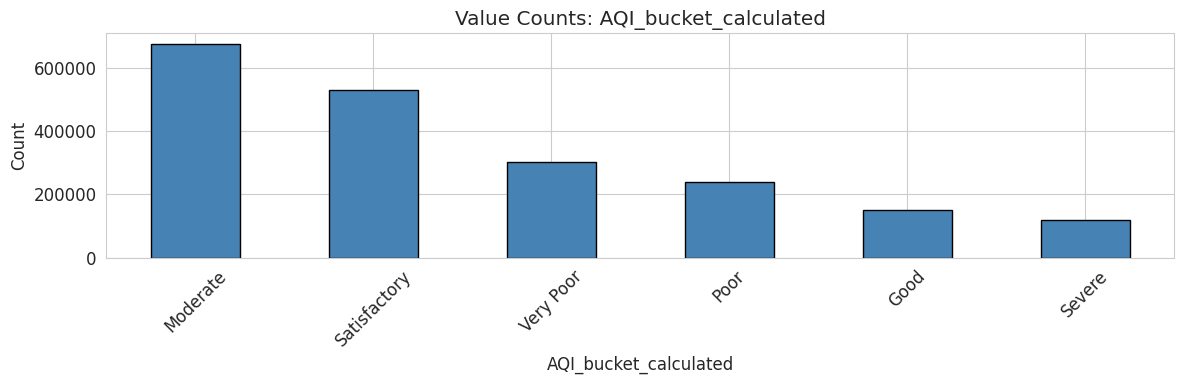

In [10]:
for col in categorical_cols:
    print(f"\n{'='*50}")
    print(f"Column: {col}  |  Unique: {df[col].nunique()}")
    print(f"{'='*50}")
    vc = df[col].value_counts()
    print(vc.head(20))
    
    if df[col].nunique() <= 30:
        fig, ax = plt.subplots(figsize=(12, 4))
        vc.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
        ax.set_title(f'Value Counts: {col}')
        ax.set_ylabel('Count')
        ax.tick_params(axis='x', rotation=45)
        plt.tight_layout()
        plt.show()

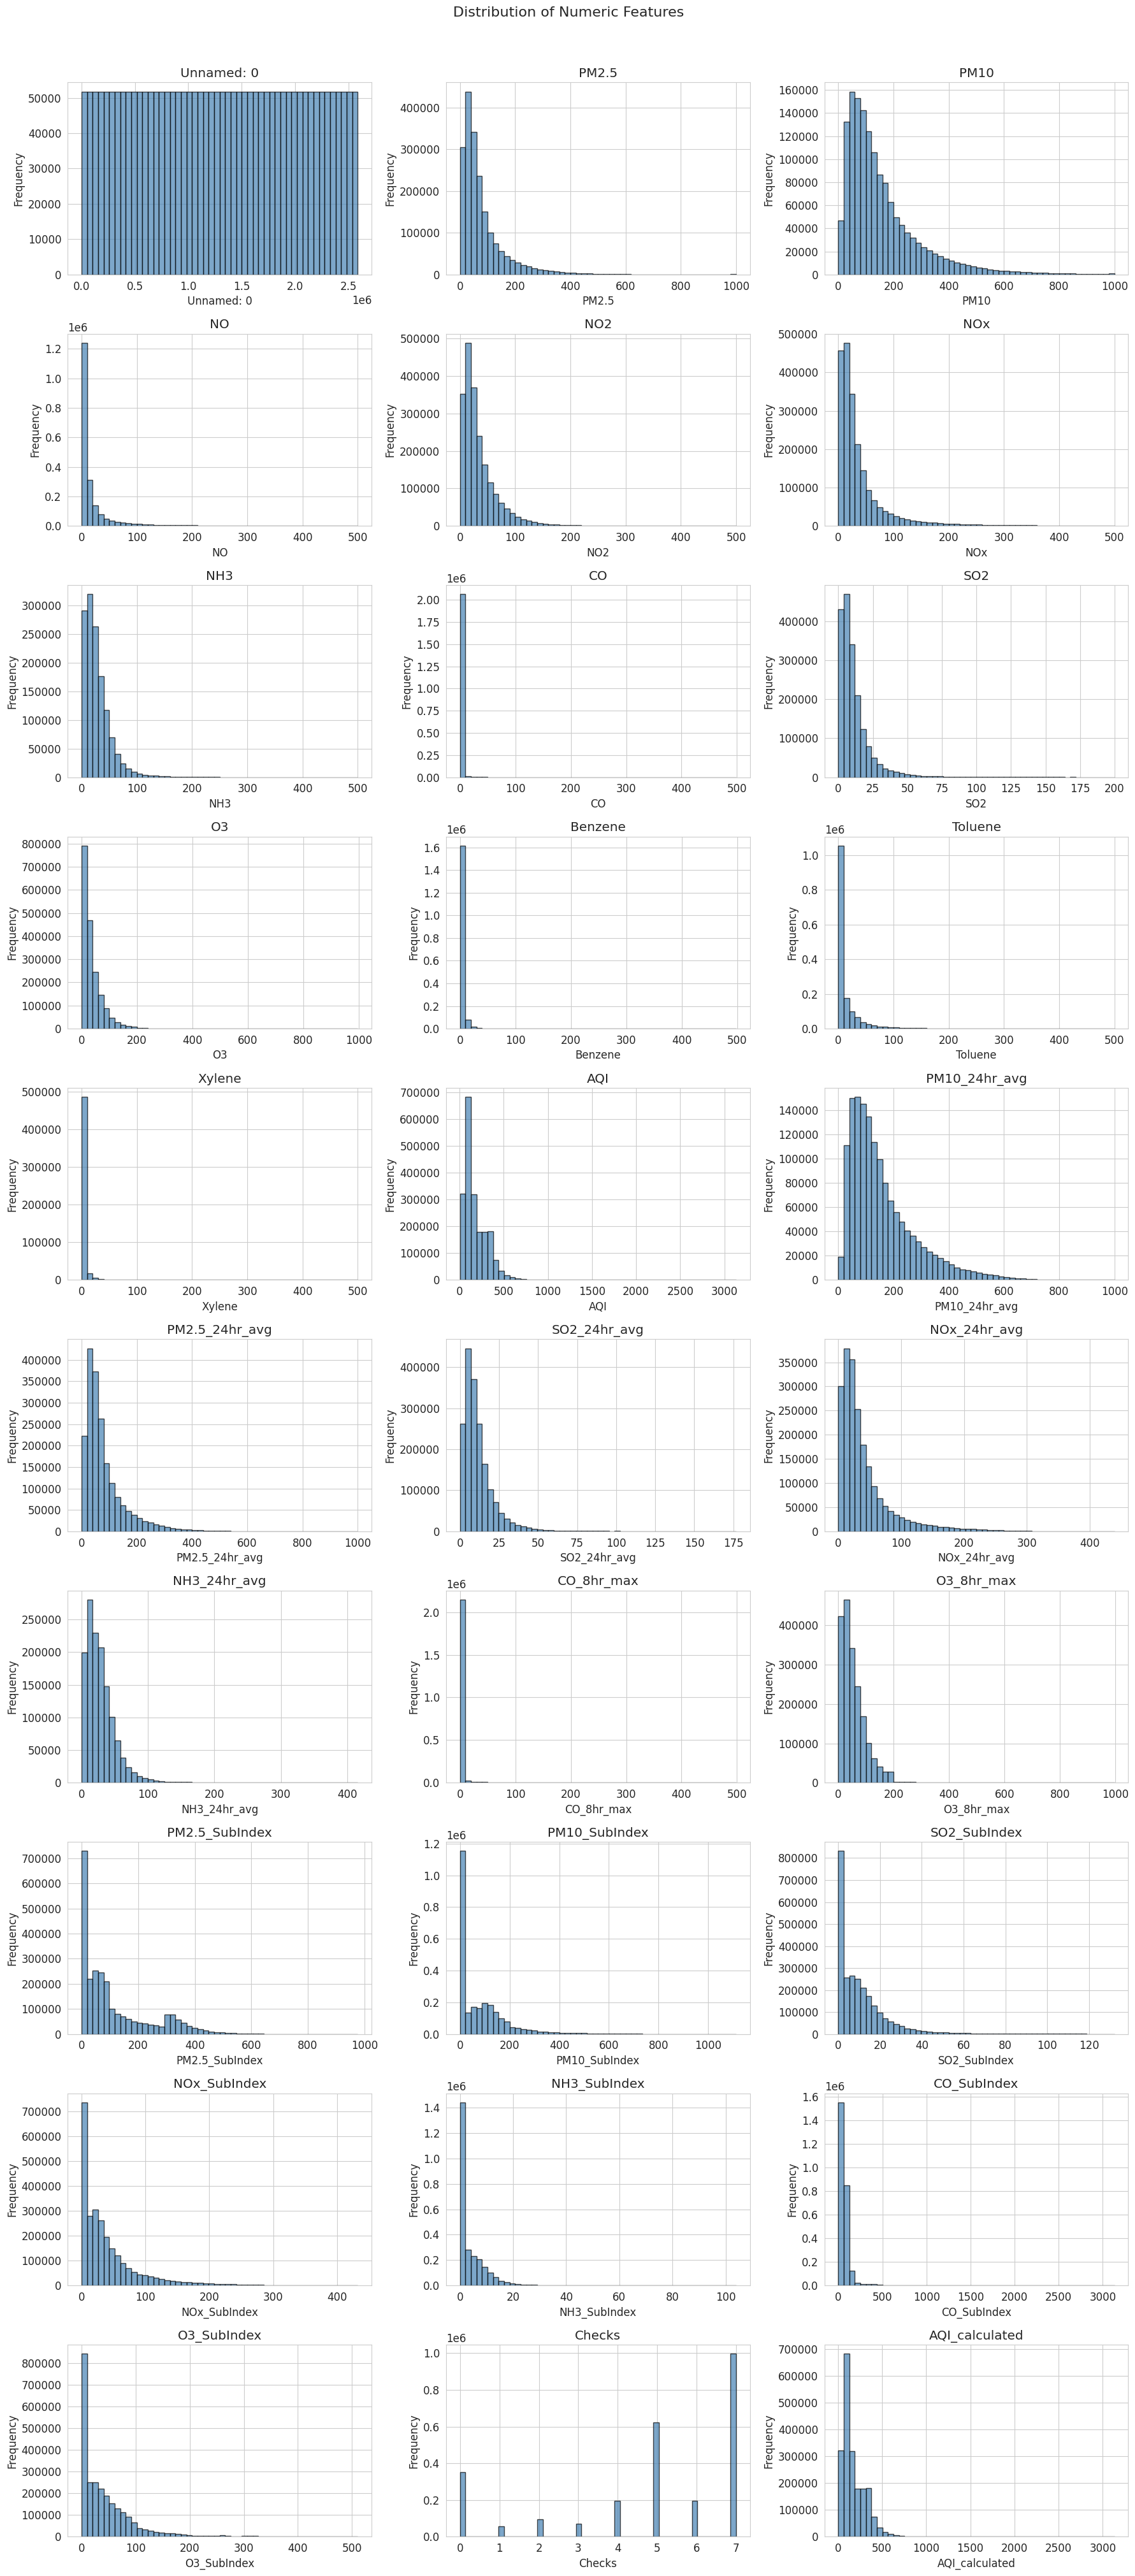

In [11]:
n_numeric = len(numeric_cols)
n_cols_plot = 3
n_rows_plot = (n_numeric + n_cols_plot - 1) // n_cols_plot

fig, axes = plt.subplots(n_rows_plot, n_cols_plot, figsize=(6 * n_cols_plot, 4 * n_rows_plot))
axes = axes.flatten() if n_numeric > 1 else [axes]

for i, col in enumerate(numeric_cols):
    ax = axes[i]
    df[col].dropna().hist(bins=50, ax=ax, color='steelblue', edgecolor='black', alpha=0.7)
    ax.set_title(f'{col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribution of Numeric Features', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

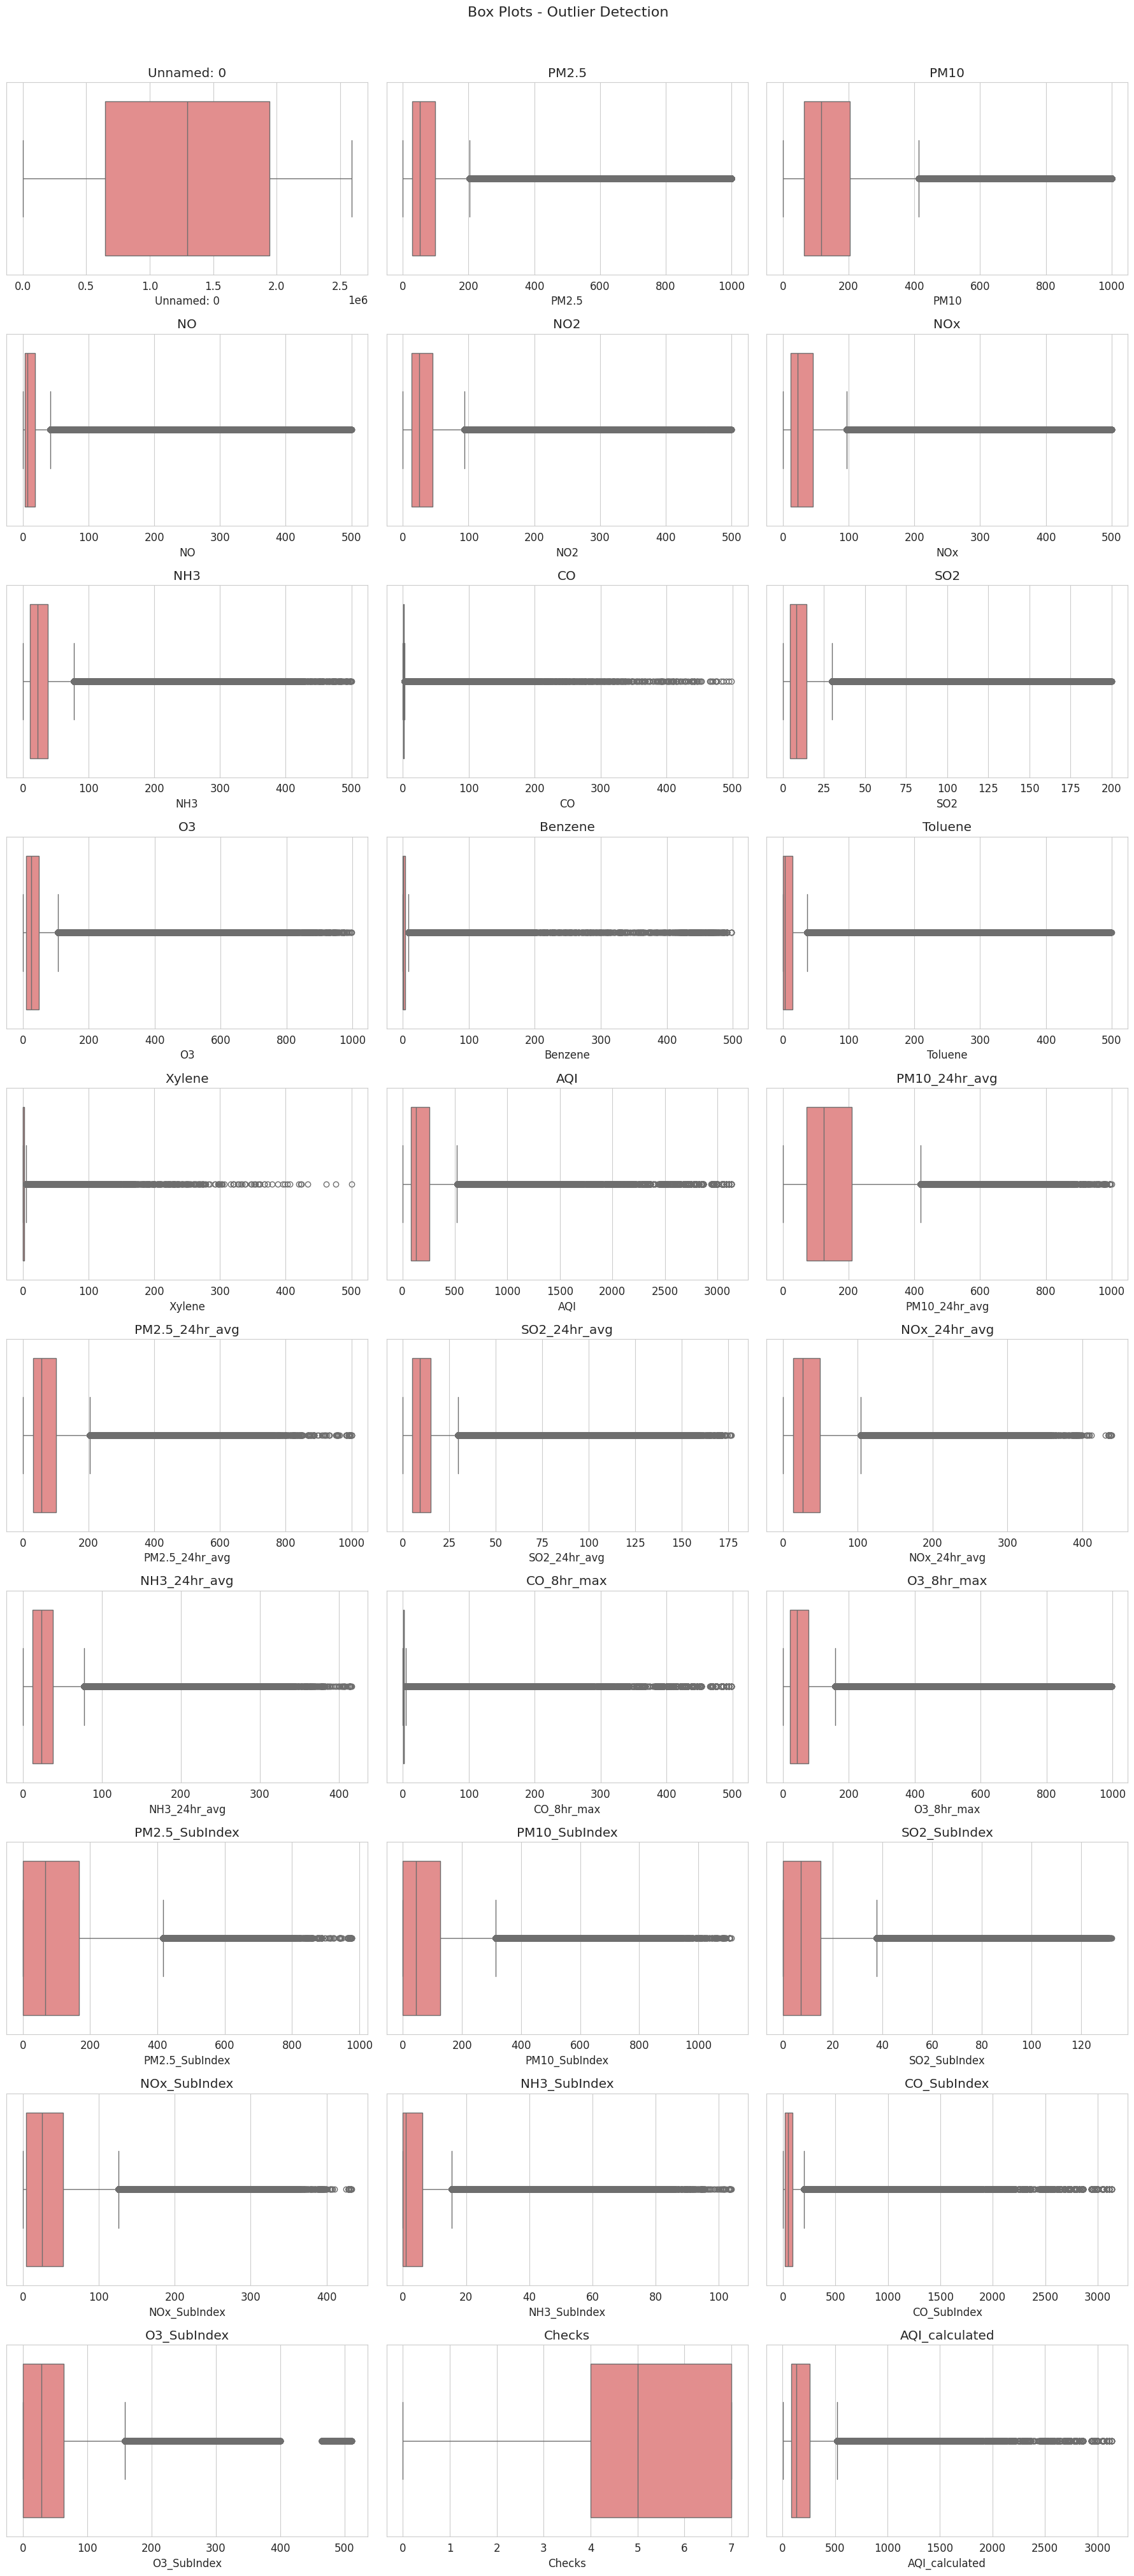

In [12]:
fig, axes = plt.subplots(n_rows_plot, n_cols_plot, figsize=(6 * n_cols_plot, 4 * n_rows_plot))
axes = axes.flatten() if n_numeric > 1 else [axes]

for i, col in enumerate(numeric_cols):
    ax = axes[i]
    sns.boxplot(x=df[col].dropna(), ax=ax, color='lightcoral')
    ax.set_title(f'{col}')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Box Plots - Outlier Detection', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

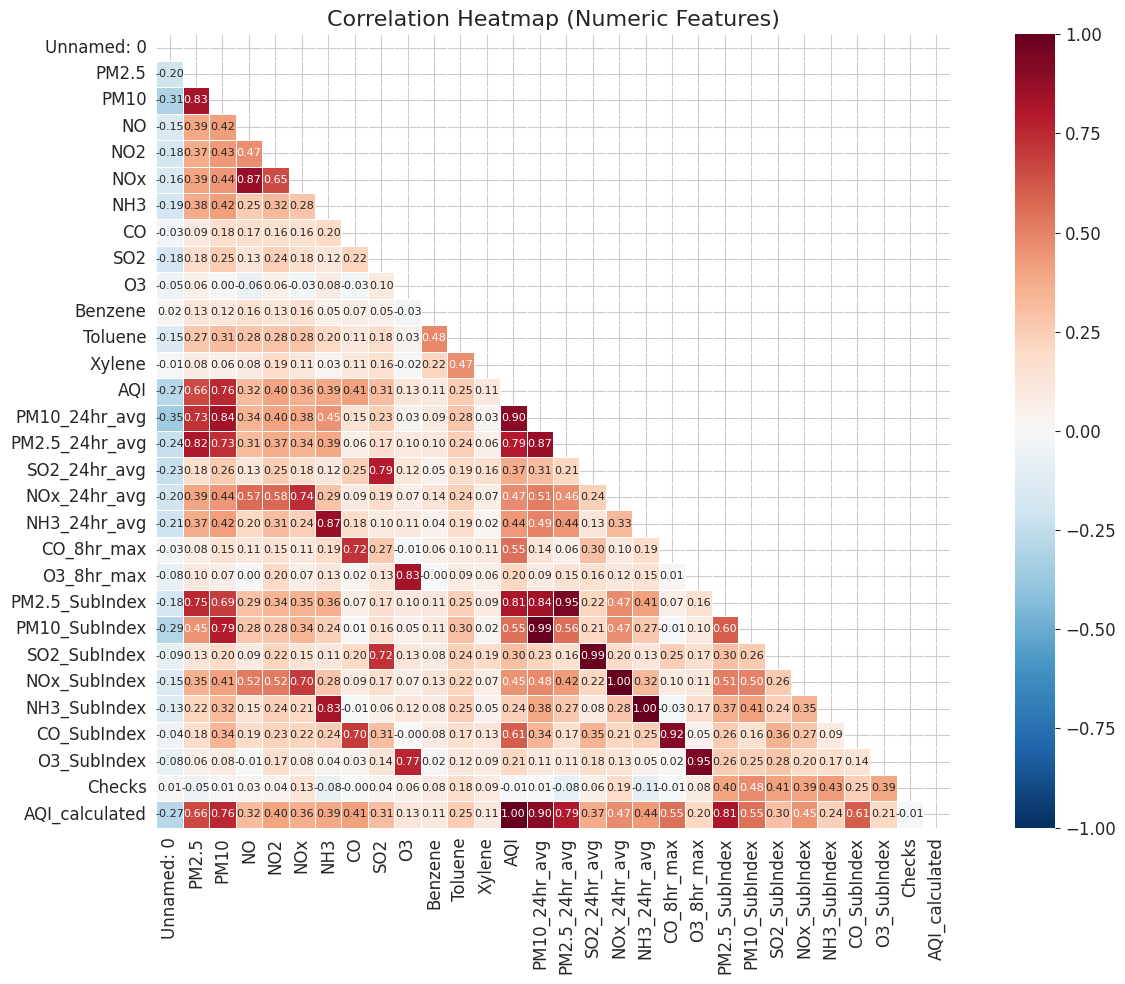

In [13]:
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax, vmin=-1, vmax=1,
            annot_kws={'size': 8})
ax.set_title('Correlation Heatmap (Numeric Features)', fontsize=16)
plt.tight_layout()
plt.show()

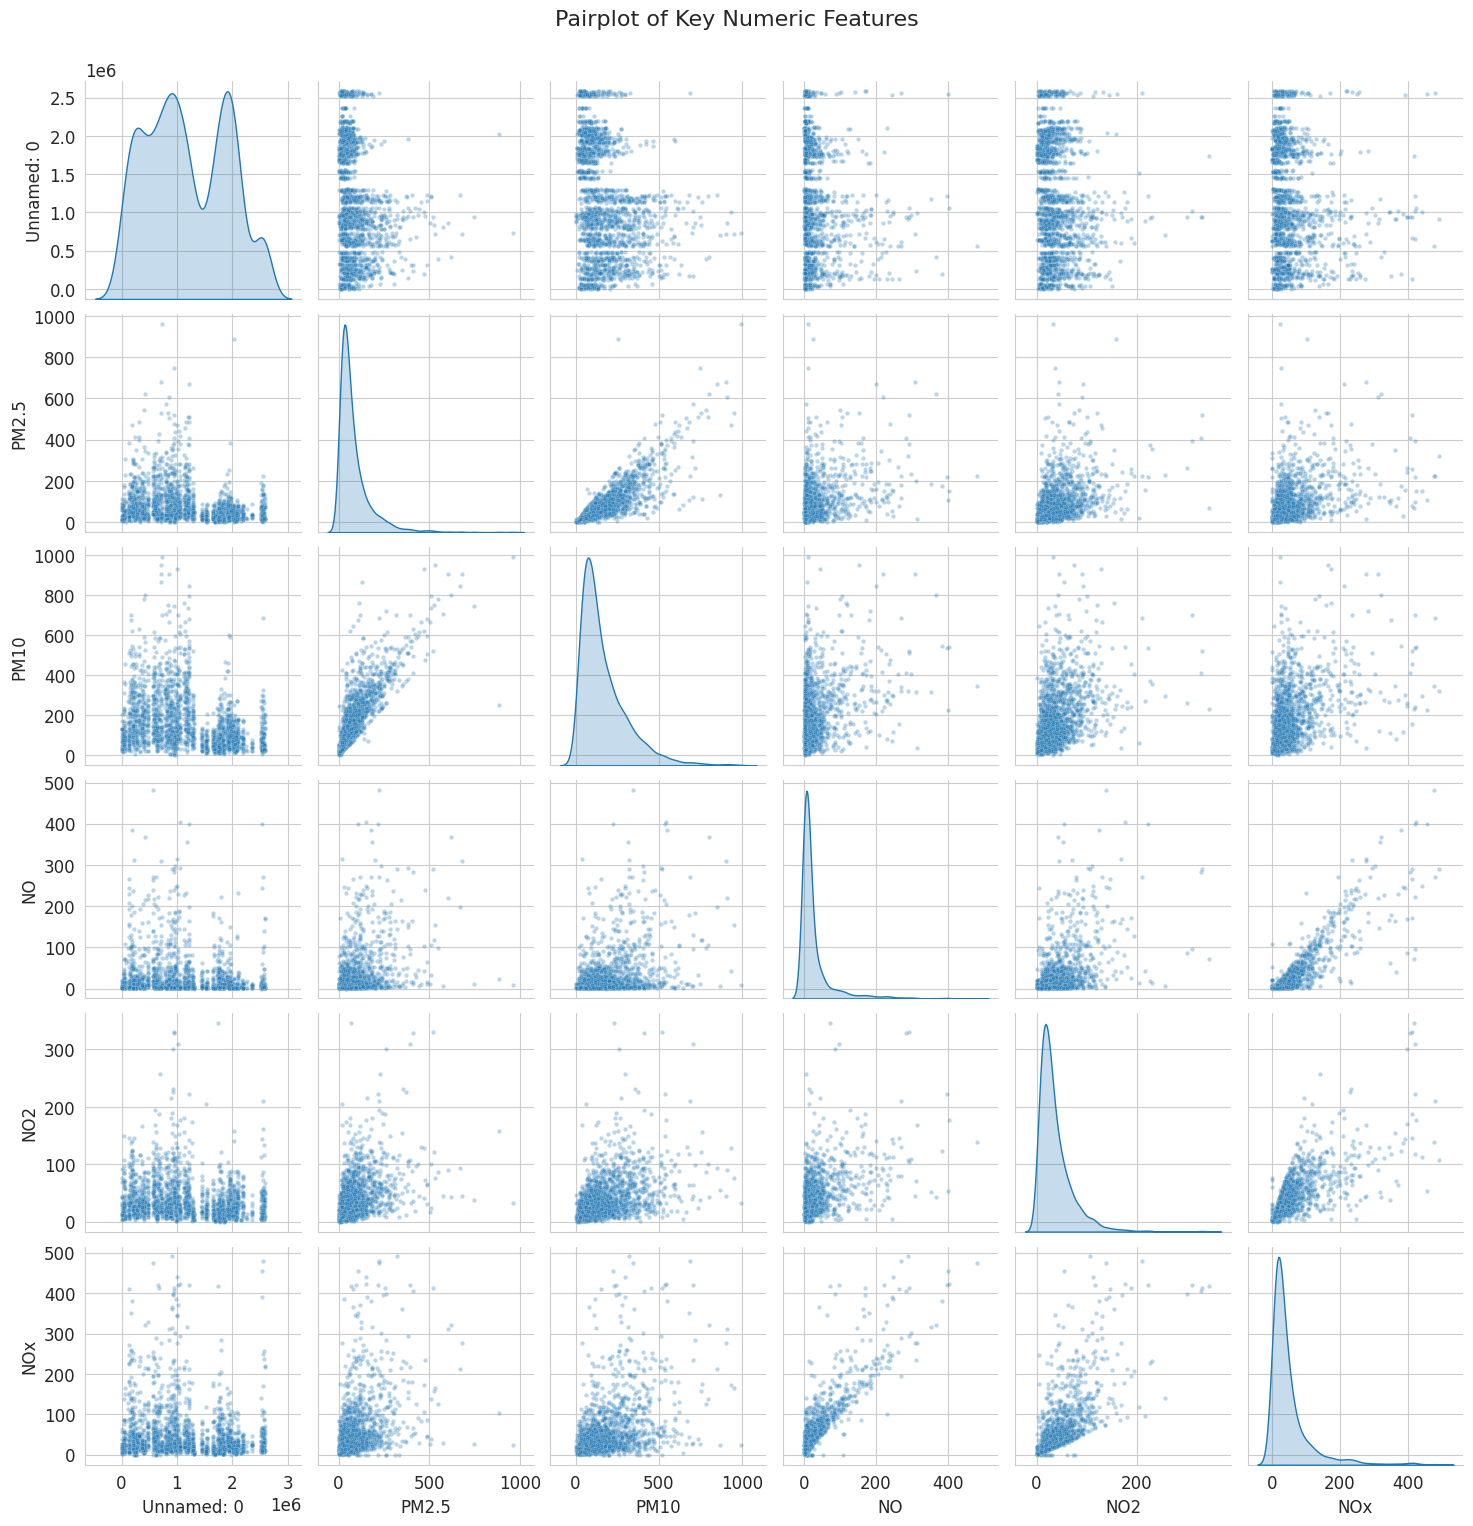

In [14]:
# Pairplot on a subset of features (max 6 for readability)
pair_cols = numeric_cols[:6]
sample_pair = df[pair_cols].dropna().sample(min(2000, len(df)), random_state=42)

g = sns.pairplot(sample_pair, diag_kind='kde', plot_kws={'alpha': 0.3, 's': 10})
g.figure.suptitle('Pairplot of Key Numeric Features', y=1.02, fontsize=16)
plt.show()

In [15]:
# ======================================================================
# PREPROCESSING CONFIGURATION
# ======================================================================
# Identify AQI-related target column
target_candidates = [c for c in numeric_cols if 'aqi' in c.lower()]
if len(target_candidates) > 0:
    TARGET_COL = target_candidates[0]
else:
    TARGET_COL = numeric_cols[-1]  # default: last numeric column

# Feature columns: all numeric except the target
FEATURE_COLS = [c for c in numeric_cols if c != TARGET_COL]

print(f"Target column:  {TARGET_COL}")
print(f"Feature columns ({len(FEATURE_COLS)}): {FEATURE_COLS}")
print(f"\nTarget stats:\n{df[TARGET_COL].describe()}")

Target column:  AQI
Feature columns (29): ['Unnamed: 0', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'PM10_24hr_avg', 'PM2.5_24hr_avg', 'SO2_24hr_avg', 'NOx_24hr_avg', 'NH3_24hr_avg', 'CO_8hr_max', 'O3_8hr_max', 'PM2.5_SubIndex', 'PM10_SubIndex', 'SO2_SubIndex', 'NOx_SubIndex', 'NH3_SubIndex', 'CO_SubIndex', 'O3_SubIndex', 'Checks', 'AQI_calculated']

Target stats:
count    2.018893e+06
mean     1.801730e+02
std      1.404095e+02
min      5.000000e+00
25%      8.400000e+01
50%      1.310000e+02
75%      2.590000e+02
max      3.133000e+03
Name: AQI, dtype: float64


In [21]:
# ======================================================================
# MISSING VALUE HANDLING
# ======================================================================

# Determine grouping column if available (station/city level imputation)
group_col_for_impute = None
for c in categorical_cols:
    if 'station' in c.lower() or 'city' in c.lower() or 'site' in c.lower():
        group_col_for_impute = c
        break

all_cols_needed = FEATURE_COLS + [TARGET_COL]
if date_col:
    all_cols_needed = [date_col] + all_cols_needed
if group_col_for_impute:
    all_cols_needed = [group_col_for_impute] + all_cols_needed
    # Remove duplicates while preserving order
    all_cols_needed = list(dict.fromkeys(all_cols_needed))

df_clean = df[all_cols_needed].copy()

print(f"Before cleaning: {df_clean.shape}")
print(f"Missing values:\n{df_clean[FEATURE_COLS + [TARGET_COL]].isna().sum()}\n")

# Step 1: Drop rows where target is NaN
df_clean = df_clean.dropna(subset=[TARGET_COL])
print(f"After dropping NaN target: {df_clean.shape}")

# Step 2: Forward fill then backward fill within groups (if grouped) for features
if group_col_for_impute:
    df_clean[FEATURE_COLS] = df_clean.groupby(group_col_for_impute)[FEATURE_COLS].transform(
        lambda x: x.fillna(method='ffill').fillna(method='bfill')
    )
else:
    df_clean[FEATURE_COLS] = df_clean[FEATURE_COLS].fillna(method='ffill').fillna(method='bfill')

# Step 3: Fill remaining NaN with column median
df_clean[FEATURE_COLS] = df_clean[FEATURE_COLS].fillna(df_clean[FEATURE_COLS].median())

# Step 4: Drop any remaining rows with NaN
df_clean = df_clean.dropna(subset=FEATURE_COLS + [TARGET_COL])

print(f"After imputation & cleanup: {df_clean.shape}")
print(f"Remaining NaN: {df_clean[FEATURE_COLS + [TARGET_COL]].isna().sum().sum()}")
df_clean.head()

Before cleaning: (2589083, 32)
Missing values:
Unnamed: 0              0
PM2.5              647689
PM10              1119252
NO                 553711
NO2                528973
NOx                490808
NH3               1236618
CO                 499302
SO2                742737
O3                 725973
Benzene            861579
Toluene           1042366
Xylene            2075104
PM10_24hr_avg     1125900
PM2.5_24hr_avg     659017
SO2_24hr_avg       743995
NOx_24hr_avg       501625
NH3_24hr_avg      1244221
CO_8hr_max         387630
O3_8hr_max         660727
PM2.5_SubIndex          0
PM10_SubIndex           0
SO2_SubIndex            0
NOx_SubIndex            0
NH3_SubIndex            0
CO_SubIndex             0
O3_SubIndex             0
Checks                  0
AQI_calculated     571111
AQI                570190
dtype: int64

After dropping NaN target: (2018893, 32)


/tmp/ipykernel_515218/576870327.py:32: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  lambda x: x.fillna(method='ffill').fillna(method='bfill')
/tmp/ipykernel_515218/576870327.py:32: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  lambda x: x.fillna(method='ffill').fillna(method='bfill')


After imputation & cleanup: (2018893, 32)
Remaining NaN: 0


,StationId,Datetime,Unnamed: 0,PM2.5,PM10,NO,NO2,NOx,NH3,CO,...,PM2.5_SubIndex,PM10_SubIndex,SO2_SubIndex,NOx_SubIndex,NH3_SubIndex,CO_SubIndex,O3_SubIndex,Checks,AQI_calculated,AQI
212,DL013,2015-01-01 16:00:00,485892,205.00,113.75,7.23,12.00,17.01,38.34,21.00,...,361.423558,0.0,5.770313,28.219531,10.420781,361.764706,0.000,5,362.0,362.0
219,DL007,2015-01-01 16:00:00,285159,218.02,340.66,22.38,48.42,70.80,22.22,0.95,...,551.254327,0.0,0.000000,111.072500,0.000000,47.500000,242.375,4,551.0,551.0
227,DL007,2015-01-01 17:00:00,285160,164.74,257.40,18.79,49.50,68.28,22.22,0.95,...,538.499095,0.0,0.000000,109.731765,0.000000,47.500000,242.375,4,538.0,538.0
232,DL013,2015-01-01 17:00:00,485893,217.50,113.75,12.23,13.00,21.36,40.96,23.50,...,362.222172,0.0,6.791176,28.130147,10.410147,361.764706,0.000,5,362.0,362.0
245,DL007,2015-01-01 18:00:00,285161,224.88,351.01,23.97,49.15,73.13,22.22,0.89,...,529.731197,0.0,0.000000,108.809444,0.000000,47.500000,242.375,4,530.0,530.0


In [22]:
# ======================================================================
# SEQUENCE CREATION PARAMETERS
# ======================================================================
SEQUENCE_LENGTH = 30       # Number of time steps per sequence
FORECAST_HORIZON = 1       # Predict 1 step ahead
TRAIN_RATIO = 0.7
VAL_RATIO = 0.15
TEST_RATIO = 0.15
BATCH_SIZE = 64

print(f"Sequence Length:    {SEQUENCE_LENGTH}")
print(f"Forecast Horizon:  {FORECAST_HORIZON}")
print(f"Train/Val/Test:    {TRAIN_RATIO}/{VAL_RATIO}/{TEST_RATIO}")
print(f"Batch Size:        {BATCH_SIZE}")

Sequence Length:    30
Forecast Horizon:  1
Train/Val/Test:    0.7/0.15/0.15
Batch Size:        64


In [23]:
# ======================================================================
# NORMALIZATION / DENORMALIZATION UTILITIES
# ======================================================================

class Normalizer:
    """Handles MinMax normalization and denormalization for features and target."""
    
    def __init__(self, feature_range=(0, 1)):
        self.feature_scaler = MinMaxScaler(feature_range=feature_range)
        self.target_scaler = MinMaxScaler(feature_range=feature_range)
        self._is_fitted = False
    
    def fit(self, features: np.ndarray, target: np.ndarray):
        """Fit scalers on training data only."""
        self.feature_scaler.fit(features)
        self.target_scaler.fit(target.reshape(-1, 1))
        self._is_fitted = True
        return self
    
    def transform_features(self, features: np.ndarray) -> np.ndarray:
        assert self._is_fitted, "Call fit() first!"
        return self.feature_scaler.transform(features)
    
    def transform_target(self, target: np.ndarray) -> np.ndarray:
        assert self._is_fitted, "Call fit() first!"
        return self.target_scaler.transform(target.reshape(-1, 1)).flatten()
    
    def inverse_transform_features(self, features: np.ndarray) -> np.ndarray:
        assert self._is_fitted, "Call fit() first!"
        return self.feature_scaler.inverse_transform(features)
    
    def inverse_transform_target(self, target: np.ndarray) -> np.ndarray:
        """Denormalize predictions back to original scale."""
        assert self._is_fitted, "Call fit() first!"
        return self.target_scaler.inverse_transform(target.reshape(-1, 1)).flatten()
    
    def get_params(self):
        """Return scaler parameters for saving."""
        return {
            'feature_min': self.feature_scaler.data_min_,
            'feature_max': self.feature_scaler.data_max_,
            'target_min': self.target_scaler.data_min_,
            'target_max': self.target_scaler.data_max_,
        }

normalizer = Normalizer(feature_range=(0, 1))
print("Normalizer class defined.")

Normalizer class defined.


In [24]:
# ======================================================================
# SEQUENCE CREATION
# ======================================================================

def create_sequences(features: np.ndarray, target: np.ndarray, 
                     seq_length: int, forecast_horizon: int = 1):
    """
    Create sliding window sequences.
    
    Args:
        features: (N, num_features) array
        target: (N,) array
        seq_length: number of past time steps
        forecast_horizon: how many steps ahead to predict
    
    Returns:
        X: (num_sequences, seq_length, num_features)
        y: (num_sequences,) — target at time t+forecast_horizon
    """
    X, y = [], []
    for i in range(len(features) - seq_length - forecast_horizon + 1):
        X.append(features[i : i + seq_length])
        y.append(target[i + seq_length + forecast_horizon - 1])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

print("create_sequences function defined.")

create_sequences function defined.


In [25]:
# ======================================================================
# BUILD SEQUENCES PER GROUP (or globally)
# ======================================================================

def build_sequences_per_group(df_clean, group_col, feature_cols, target_col, 
                               normalizer, seq_length, forecast_horizon,
                               train_ratio, val_ratio):
    """
    For each group (station/city), do chronological split, then create sequences.
    The normalizer is fit ONLY on the training portion.
    """
    all_train_X, all_train_y = [], []
    all_val_X, all_val_y = [], []
    all_test_X, all_test_y = [], []
    
    if group_col is not None:
        groups = df_clean[group_col].unique()
    else:
        groups = ['__all__']
    
    # First pass: collect all training data to fit the normalizer
    train_features_all = []
    train_target_all = []
    
    for grp in groups:
        if group_col is not None:
            grp_df = df_clean[df_clean[group_col] == grp].sort_values(date_col if date_col else feature_cols[0])
        else:
            grp_df = df_clean.copy()
        
        n = len(grp_df)
        if n < seq_length + forecast_horizon + 10:
            continue  # skip groups that are too short
        
        train_end = int(n * train_ratio)
        
        train_features_all.append(grp_df[feature_cols].values[:train_end])
        train_target_all.append(grp_df[target_col].values[:train_end])
    
    # Fit normalizer on ALL training data across groups
    train_features_concat = np.concatenate(train_features_all, axis=0)
    train_target_concat = np.concatenate(train_target_all, axis=0)
    normalizer.fit(train_features_concat, train_target_concat)
    print(f"Normalizer fitted on {train_features_concat.shape[0]} training samples.")
    
    # Second pass: normalize and create sequences
    skipped = 0
    for grp in groups:
        if group_col is not None:
            grp_df = df_clean[df_clean[group_col] == grp].sort_values(date_col if date_col else feature_cols[0])
        else:
            grp_df = df_clean.copy()
        
        n = len(grp_df)
        if n < seq_length + forecast_horizon + 10:
            skipped += 1
            continue
        
        features = grp_df[feature_cols].values
        target = grp_df[target_col].values
        
        # Normalize
        features_norm = normalizer.transform_features(features)
        target_norm = normalizer.transform_target(target)
        
        # Chronological split
        train_end = int(n * train_ratio)
        val_end = int(n * (train_ratio + val_ratio))
        
        train_feat, train_tgt = features_norm[:train_end], target_norm[:train_end]
        val_feat, val_tgt = features_norm[train_end - seq_length:val_end], target_norm[train_end - seq_length:val_end]
        test_feat, test_tgt = features_norm[val_end - seq_length:], target_norm[val_end - seq_length:]
        
        # Create sequences
        if len(train_feat) >= seq_length + forecast_horizon:
            X, y = create_sequences(train_feat, train_tgt, seq_length, forecast_horizon)
            all_train_X.append(X)
            all_train_y.append(y)
        
        if len(val_feat) >= seq_length + forecast_horizon:
            X, y = create_sequences(val_feat, val_tgt, seq_length, forecast_horizon)
            all_val_X.append(X)
            all_val_y.append(y)
        
        if len(test_feat) >= seq_length + forecast_horizon:
            X, y = create_sequences(test_feat, test_tgt, seq_length, forecast_horizon)
            all_test_X.append(X)
            all_test_y.append(y)
    
    print(f"Processed {len(groups) - skipped} groups, skipped {skipped} (too short).")
    
    train_X = np.concatenate(all_train_X, axis=0)
    train_y = np.concatenate(all_train_y, axis=0)
    val_X = np.concatenate(all_val_X, axis=0)
    val_y = np.concatenate(all_val_y, axis=0)
    test_X = np.concatenate(all_test_X, axis=0)
    test_y = np.concatenate(all_test_y, axis=0)
    
    return train_X, train_y, val_X, val_y, test_X, test_y

# Build
train_X, train_y, val_X, val_y, test_X, test_y = build_sequences_per_group(
    df_clean, group_col_for_impute, FEATURE_COLS, TARGET_COL,
    normalizer, SEQUENCE_LENGTH, FORECAST_HORIZON, TRAIN_RATIO, VAL_RATIO
)

print(f"\n{'='*60}")
print(f"SEQUENCE SHAPES (batch, seq_len, features)")
print(f"{'='*60}")
print(f"Train X: {train_X.shape}  |  Train y: {train_y.shape}")
print(f"Val   X: {val_X.shape}  |  Val   y: {val_y.shape}")
print(f"Test  X: {test_X.shape}  |  Test  y: {test_y.shape}")

Normalizer fitted on 1413174 training samples.
Processed 109 groups, skipped 0 (too short).

SEQUENCE SHAPES (batch, seq_len, features)
Train X: (1409904, 30, 29)  |  Train y: (1409904,)
Val   X: (302828, 30, 29)  |  Val   y: (302828,)
Test  X: (302891, 30, 29)  |  Test  y: (302891,)


In [26]:
# ======================================================================
# PYTORCH DATASET
# ======================================================================

class TimeSeriesDataset(Dataset):
    """
    PyTorch Dataset for time series. 
    Returns (X, y) where X has shape (seq_length, num_features).
    When batched by DataLoader: (batch_size, seq_length, num_features).
    """
    
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Create datasets
train_dataset = TimeSeriesDataset(train_X, train_y)
val_dataset = TimeSeriesDataset(val_X, val_y)
test_dataset = TimeSeriesDataset(test_X, test_y)

print(f"Train dataset: {len(train_dataset)} samples")
print(f"Val   dataset: {len(val_dataset)} samples")
print(f"Test  dataset: {len(test_dataset)} samples")

Train dataset: 1409904 samples
Val   dataset: 302828 samples
Test  dataset: 302891 samples


In [27]:
# ======================================================================
# DATALOADERS
# ======================================================================

train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, 
                               num_workers=2, pin_memory=True, drop_last=False)
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, 
                             num_workers=2, pin_memory=True, drop_last=False)
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, 
                              num_workers=2, pin_memory=True, drop_last=False)

print(f"Train DataLoader: {len(train_dataloader)} batches")
print(f"Val   DataLoader: {len(val_dataloader)} batches")
print(f"Test  DataLoader: {len(test_dataloader)} batches")

Train DataLoader: 22030 batches
Val   DataLoader: 4732 batches
Test  DataLoader: 4733 batches


In [28]:
# ======================================================================
# VERIFY SHAPES — Ready for LSTM / GRU / Transformer
# ======================================================================

batch_X, batch_y = next(iter(train_dataloader))
print(f"Batch X shape: {batch_X.shape}  →  (batch_size, seq_length, num_features)")
print(f"Batch y shape: {batch_y.shape}  →  (batch_size,)")
print(f"\nX dtype: {batch_X.dtype}")
print(f"y dtype: {batch_y.dtype}")
print(f"\nX sample [0, 0, :5]: {batch_X[0, 0, :5]}")
print(f"y sample [0]:         {batch_y[0]:.4f}")

/home/rdb/Documents/nirban_documents/python_programs/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:283: UserWarning: 
    Found GPU0 Quadro P1000 which is of cuda capability 6.1.
    Minimum and Maximum cuda capability supported by this version of PyTorch is
    (7.0) - (12.0)
    
  warnings.warn(
/home/rdb/Documents/nirban_documents/python_programs/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:304: UserWarning: 
    Please install PyTorch with a following CUDA
    configurations:  12.6 following instructions at
    https://pytorch.org/get-started/locally/
    
  warnings.warn(matched_cuda_warn.format(matched_arches))
/home/rdb/Documents/nirban_documents/python_programs/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:326: UserWarning: 
Quadro P1000 with CUDA capability sm_61 is not compatible with the current PyTorch installation.
The current PyTorch install supports CUDA capabilities sm_70 sm_75 sm_80 sm_86 sm_90 sm_100 sm_120.
If you want to use the

Batch X shape: torch.Size([64, 30, 29])  →  (batch_size, seq_length, num_features)
Batch y shape: torch.Size([64])  →  (batch_size,)

X dtype: torch.float32
y dtype: torch.float32

X sample [0, 0, :5]: tensor([0.4491, 0.0520, 0.3480, 0.0135, 0.0286])
y sample [0]:         0.0902


In [29]:
# ======================================================================
# DENORMALIZATION VERIFICATION
# ======================================================================

# Take a batch of predictions (use actual targets as proxy)
sample_y_norm = batch_y.numpy()
sample_y_denorm = normalizer.inverse_transform_target(sample_y_norm)

print("Normalized target (first 10):", sample_y_norm[:10])
print("Denormalized target (first 10):", sample_y_denorm[:10])
print(f"\nOriginal target stats: mean={df_clean[TARGET_COL].mean():.2f}, std={df_clean[TARGET_COL].std():.2f}")
print(f"Denormalized sample: mean={sample_y_denorm.mean():.2f}, std={sample_y_denorm.std():.2f}")

Normalized target (first 10): [0.09015346 0.0418798  0.03324808 0.09462915 0.125      0.06297954
 0.02397698 0.01950128 0.01694373 0.0230179 ]
Denormalized target (first 10): [287.       136.       109.       300.99997  396.       202.
  80.        66.        58.000004  77.      ]

Original target stats: mean=180.17, std=140.41
Denormalized sample: mean=188.69, std=142.50


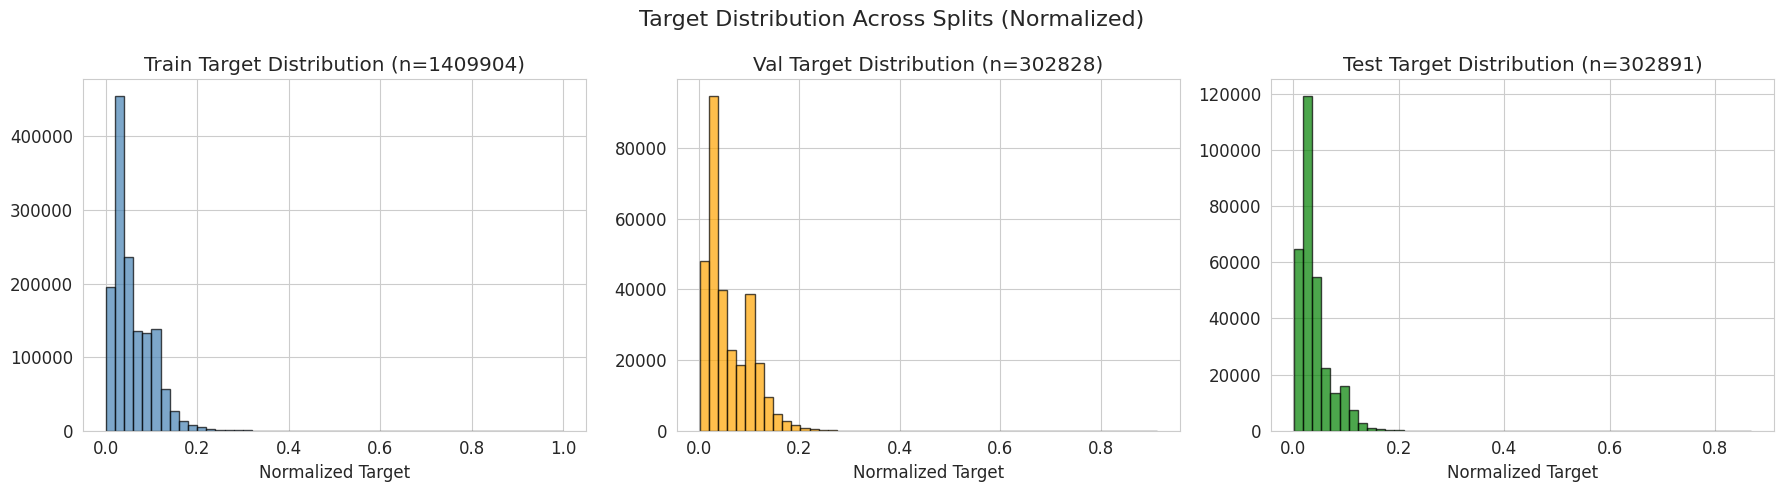

In [30]:
# ======================================================================
# VISUALIZE NORMALIZED DATA
# ======================================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Train
axes[0].hist(train_y, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_title(f'Train Target Distribution (n={len(train_y)})')
axes[0].set_xlabel('Normalized Target')

# Val
axes[1].hist(val_y, bins=50, color='orange', edgecolor='black', alpha=0.7)
axes[1].set_title(f'Val Target Distribution (n={len(val_y)})')
axes[1].set_xlabel('Normalized Target')

# Test
axes[2].hist(test_y, bins=50, color='green', edgecolor='black', alpha=0.7)
axes[2].set_title(f'Test Target Distribution (n={len(test_y)})')
axes[2].set_xlabel('Normalized Target')

plt.suptitle('Target Distribution Across Splits (Normalized)', fontsize=16)
plt.tight_layout()
plt.show()

In [31]:
# ======================================================================
# SUMMARY
# ======================================================================
config = {
    'dataset': 'AQI_India',
    'target_col': TARGET_COL,
    'feature_cols': FEATURE_COLS,
    'num_features': len(FEATURE_COLS),
    'seq_length': SEQUENCE_LENGTH,
    'forecast_horizon': FORECAST_HORIZON,
    'batch_size': BATCH_SIZE,
    'train_samples': len(train_dataset),
    'val_samples': len(val_dataset),
    'test_samples': len(test_dataset),
    'train_batches': len(train_dataloader),
    'val_batches': len(val_dataloader),
    'test_batches': len(test_dataloader),
    'normalizer_params': normalizer.get_params(),
}

print("=" * 60)
print("DATASET CONFIGURATION SUMMARY")
print("=" * 60)
for k, v in config.items():
    if k != 'normalizer_params' and k != 'feature_cols':
        print(f"  {k:25s}: {v}")
print(f"  {'feature_cols':25s}: {config['feature_cols']}")
print("=" * 60)
print("\n✅ DataLoaders ready for LSTM / GRU / Transformer training!")
print(f"   Input shape per batch: ({BATCH_SIZE}, {SEQUENCE_LENGTH}, {len(FEATURE_COLS)})")
print(f"   Output shape per batch: ({BATCH_SIZE},)")

# Save config to pickle for downstream use
import pickle
config_path = os.path.join(DATA_PATH, 'dataloader_config.pkl')
with open(config_path, 'wb') as f:
    pickle.dump({
        'config': config,
        'normalizer': normalizer,
    }, f)
print(f"\n💾 Config saved to: {config_path}")

DATASET CONFIGURATION SUMMARY
  dataset                  : AQI_India
  target_col               : AQI
  num_features             : 29
  seq_length               : 30
  forecast_horizon         : 1
  batch_size               : 64
  train_samples            : 1409904
  val_samples              : 302828
  test_samples             : 302891
  train_batches            : 22030
  val_batches              : 4732
  test_batches             : 4733
  feature_cols             : ['Unnamed: 0', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'PM10_24hr_avg', 'PM2.5_24hr_avg', 'SO2_24hr_avg', 'NOx_24hr_avg', 'NH3_24hr_avg', 'CO_8hr_max', 'O3_8hr_max', 'PM2.5_SubIndex', 'PM10_SubIndex', 'SO2_SubIndex', 'NOx_SubIndex', 'NH3_SubIndex', 'CO_SubIndex', 'O3_SubIndex', 'Checks', 'AQI_calculated']

✅ DataLoaders ready for LSTM / GRU / Transformer training!
   Input shape per batch: (64, 30, 29)
   Output shape per batch: (64,)

💾 Config saved to: /home/rdb/Docume